<div style="border:solid green 2px; padding: 20px">
    
<b>Андрей, привет!</b> Мы рады тебя видеть на территории код-ревьюеров. 😎 Ты проделал большую работу над проектом, но давай познакомимся и сделаем его еще лучше! У нас тут своя атмосфера и несколько правил:


1. Это снова Александр Матвеевский. Я работаю код-ревьюером, моя основная цель — не указать на совершенные тобою ошибки, а поделиться своим опытом и помочь тебе стать аналитиком данных.
2. Общаемся на ты.
3. Если хочешь написать, спросить - не нужно стесняться. Только выбери свой цвет для комментария.  
4. Это учебный проект, тут можно не бояться сделать ошибку.  
5. У нас с тобой 6 попыток для сдачи проекта   
6. Let's Go!

---

Я буду красить комментарии цветом, пожалуйста, не удаляй их:

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

Такой комментарий нужно исправить обязательно, он критически влияет на удачное выполнение проекта.
</div>
    
---

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__


Такой комментарий является рекомендацией или советом. Можешь использовать их на своё усмотрение.
</div>

---

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Такой комментарий  говорит о том, что было сделано что-то качественное и правильное =)
</div>
    
---
    
Предлагаю работать над проектом в диалоге: если ты что-то меняешь в проекте или отвечаешь на мои комментарии — пиши об этом. Мне будет легче отследить изменения, если ты выделишь свои комментарии:   
    
<div class="alert alert-info"> <b>Комментарии студента:</b> Например, вот так.</div>
    
Всё это поможет выполнить повторную проверку твоего проекта оперативнее. Если будут какие-нибудь вопросы по моим комментариям, пиши, будем разбираться вместе :)    
    
---

# Проект спринта 18. Предсказание риска задержки доставки заказов для логистического оператора CargaPronto

## Цель
Разработка ML-модели для выявления заказов с высоким риском задержки доставки на этапе оформления заказа. 

### Постановка задачи в терминах машинного обучения
- Тип задачи машинного обучения: бинарная классификация.
- Целевая переменная - риск задержки доставки (0/1).
- Для добавления новых признаков следует использовать кластеризацию методом K-Means по географическим координатам и RFM-признакам клиентов.
- Визуализация кластеров при помощи t-SNE.
- Модели машинного обучения - Логистическая регрессия, градиентный бустинг (библиотека CatBoost).
- Основная метрика - ROC-AUC. Вспомогательные метрики: F1, Precision, Recall, Accuracy.
- Требования к значениям метрик:
    - ROC-AUC >= 0.75.
- Для подбора оптимального набора гиперпараметров следует использовать байесовскую оптимизацию.
- Необходимо обеспечить воспроизводимость результатов при помощи указания фиксированного значения `random_state`.

### Задачи
1. Загрузка таблиц датасета, первичный анализ.
2. Исследовательский анализ данных.
3. Объединение таблиц в датасет с единым пространством признаков.
4. Выделение обучающей, валидационной и тестовой выборок.
5. Обучение базовых моделей логистической регрессии и градиентного бустинга CatBoost.
6. Выделение кластеров по географическим признакам клиентов, визулизация результатов.
7. Выделение кластеров по RFM-признакам клиентов, визуализация результатов.
8. Обучение моделей логистической регрессии и градиентного бустинга CatBoost на наборе признаков, дополненном метками кластеров.
9. Оптимизация моделей путём подбора гиперпараметров.
10. Тестирование модели.
11. Оценка важности признаков, анализ матрицы ошибок.
12. Формулировка выводов и рекомендаций по дальнейшему усовершенствованию модели.

### Описание данных
#### **Профили уникальных клиентов**

В датасете `ds_s18_customers.csv` собрана агрегированная информация о каждом уникальном клиенте. Эти признаки содержат информацию, характеризующую пользователей с разных сторон.

**Идентификатор**

- `customer_id` — уникальный номер клиента в системе ERP. Служит ключом для связи с таблицей заказов.

**Географический профиль**

Эти показатели позволяют выделить логистические зоны и проверить гипотезу о труднодоступных районах.

- `customer_lat` — широта местонахождения клиента.
- `customer_lon` — долгота местонахождения клиента.

**Поведенческие признаки**

Большая часть поведенческих признаков в датасете собрана в соответствии с методом RMF для сегментации. Этот подход — «золотой стандарт» в ритейле и логистике, позволяющий быстро отделить лояльных клиентов от случайных покупателей. Три ключевых показателя, которые нужно собрать в рамках подхода, — это Recency (давность), Frequency (частота) и Monetary (доходность).

Вот в каких признаках выражены эти данные:

- `recency` — количество дней, прошедших с момента последнего заказа до точки отсчёта. Соответствует показателю Recency.
- `total_orders` — общее количество совершённых заказов. Соответствует показателю Frequency.
- `total_sales` — суммарная выручка, которую клиент принёс компании за всё время. Соответствует показателю Monetary.

В дополнение к ним собрано ещё два показателя — Average Discount и Return Rate:

- `avg_discount` — средний размер скидки, которую получает клиент. Это маркер чувствительности к акциям.
- `return_rate` — доля проблемных заказов (возвратов или отмен). Ключевой показатель добропорядочности клиента, влияющий на нагрузку курьеров.

#### **Заказы клиентов**

В датасете `ds_s18_orders.csv` находится таблица событий, где зафиксирован каждый факт продажи и итог доставки. Именно здесь находится наша целевая переменная.

- `order_id` — уникальный номер заказа.
- `customer_id` — идентификатор клиента. Служит ключом для связи с профилем из первой таблицы.
- `order_date` — дата и время совершения покупки.
- `category_name` — категория заказанного товара.
- `item_price` — стоимость товара в заказе.
- `shipping_mode` — выбранный режим доставки ( `Standard Class`, `First Class`, `Second Class`, `Same Day`.
- `late_delivery_risk` — результат доставки, целевая переменная:
    - `1` — заказ доставлен с задержкой;
    - `0` — заказ доставлен вовремя.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Хорошо, вводная часть имеется

## 1. Подготовка среды и загрузка данных
### 1.1. Установка библиотек

In [1]:
%pip install -q dotenv
%pip install -q -U numpy==1.26.4 scipy numba matplotlib
%pip install -q scikit-learn==1.6.1
%pip install -q greenlet==3.0.3
%pip install -q pandas==2.2.3
%pip install -q -U seaborn
%pip install -q -U jinja2
%pip install -q -U phik
%pip install -q -U optuna
%pip install -q -U joblib
%pip install -q -U catboost
%pip install -q -U shap

# Сохраним версии библиотек в requirements.txt
%pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### 1.2. Импорт необходимых библиотек

In [2]:
# Системные библиотеки
import os
import math

# Библиотеки для вычислений и работы с датасетами
import pandas as pd
import numpy as np
import phik

# Библиотеки машинного обучения
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, precision_score, roc_auc_score, \
    recall_score, precision_recall_curve, confusion_matrix, \
    classification_report
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.base import clone, BaseEstimator, TransformerMixin
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.inspection import permutation_importance

from catboost import CatBoostClassifier

# Подбор гиперпараметров
import optuna

# Оценка важности признаков
import shap

# Библиотеки для построения графиков
import seaborn as sns
import matplotlib.pyplot as plt

# Сериализация пайплайна
import joblib

# Для форматирования в HTML
from IPython.display import display, HTML, Markdown

### 1.3. Определение констант

In [3]:
# Константа для воспроизводимости
RANDOM_SEED = 42

# Базовый порог вероятности для положительного класса
BASE_THRESHOLD = 0.5

# Параметры целевой переменной
TARGET = 'late_delivery_risk'

pd.options.display.float_format = '{:.4f}'.format
pd.set_option('display.max_colwidth', None)

### 1.4. Загрузка данных

In [4]:
BASE_URL = "https://code.s3.yandex.net/"

def load_dataset(file_name, **kwargs):
    try:
        if os.path.exists(file_name):
            return pd.read_csv(file_name, **kwargs)
        else:
            return pd.read_csv(BASE_URL + file_name, **kwargs)
    except:
        print("Ошибка загрузки датасета")
        raise

def show_dataset_info(df, title):
    display(HTML(f"<h2>{title}</h2>"))
    df.info()
    display(df.head())
    display(HTML("<h3>Числовые параметры</h3>"))
    display(df.select_dtypes(include='number').describe())
    display(HTML("<h3>Кардинальность категориальных параметров</h3>"))
    display(df.select_dtypes(include='object').nunique())
    display(HTML(f"<h3>Количество полных дубликатов: {df.duplicated().sum()}</h3>"))

df_clients = load_dataset("datasets/ds_s18_customers.csv")
df_orders = load_dataset("datasets/ds_s18_orders.csv", parse_dates=['order_date'])

initial_clients_count = df_clients.shape[0]
initial_orders_count = df_orders.shape[0]

show_dataset_info(df_clients, "Сведения о клиентах")
show_dataset_info(df_orders, "Сведения о заказах")

display(HTML(f"""<h3>Количество дубликатов клиентов без customer_id: 
             {df_clients.drop(columns=['customer_id']).duplicated().sum()}</h3>"""))

print(f"Диапазон дат заказов: {df_orders['order_date'].min()} - {df_orders['order_date'].max()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20652 entries, 0 to 20651
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   customer_id   20652 non-null  int64  
 1   customer_lat  20652 non-null  float64
 2   customer_lon  20652 non-null  float64
 3   total_sales   20652 non-null  float64
 4   total_orders  20652 non-null  int64  
 5   avg_discount  20652 non-null  float64
 6   return_rate   20652 non-null  float64
 7   recency       20652 non-null  int64  
dtypes: float64(5), int64(3)
memory usage: 1.3 MB


,customer_id,customer_lat,customer_lon,total_sales,total_orders,avg_discount,return_rate,recency
0,1,25.9536,-97.5077,472.4500,1,0.0600,0.0000,793
1,2,38.3756,-104.7260,1618.6600,4,0.1260,0.0000,137
2,3,18.0254,-66.6151,3189.2000,5,0.1050,0.0000,230
3,4,33.6700,-112.2471,1480.7100,4,0.1350,0.0000,381
4,5,18.3591,-66.0779,1101.9200,3,0.1400,0.0000,458


,customer_id,customer_lat,customer_lon,total_sales,total_orders,avg_discount,return_rate,recency
count,20652.0000,20652.0000,20652.0000,20652.0000,20652.0000,20652.0000,20652.0000,20652.0000
mean,10400.2859,29.7487,-84.9501,1600.5424,3.1838,0.1017,0.0430,221.0891
std,5993.1062,9.8241,21.2539,1508.4180,2.4307,0.0483,0.1566,199.3954
min,1.0000,-33.9376,-158.0260,8.4700,1.0000,0.0000,0.0000,1.0000
25%,5208.7500,18.2661,-98.4693,254.9400,1.0000,0.0762,0.0000,76.0000
50%,10407.5000,33.2164,-76.7596,1294.5050,3.0000,0.1000,0.0000,160.0000
75%,15594.2500,39.2922,-66.3706,2621.1400,5.0000,0.1230,0.0000,308.0000
max,20757.0000,48.7819,115.2631,9436.6101,15.0000,0.2500,1.0000,1126.0000


Series([], dtype: float64)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   order_id            180519 non-null  int64         
 1   customer_id         180519 non-null  int64         
 2   late_delivery_risk  180519 non-null  int64         
 3   shipping_mode       180519 non-null  object        
 4   category_name       180519 non-null  object        
 5   order_date          180519 non-null  datetime64[ns]
 6   item_price          180519 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(3), object(2)
memory usage: 9.6+ MB


,order_id,customer_id,late_delivery_risk,shipping_mode,category_name,order_date,item_price
0,180517,20755,0,Standard Class,Sporting Goods,2018-01-31 22:56:00,327.7500
1,179254,19492,1,Standard Class,Sporting Goods,2018-01-13 12:27:00,327.7500
2,179253,19491,0,Standard Class,Sporting Goods,2018-01-13 12:06:00,327.7500
3,179252,19490,0,Standard Class,Sporting Goods,2018-01-13 11:45:00,327.7500
4,179251,19489,0,Standard Class,Sporting Goods,2018-01-13 11:24:00,327.7500


,order_id,customer_id,late_delivery_risk,item_price
count,180519.0000,180519.0000,180519.0000,180519.0000
mean,90260.0000,6691.3795,0.5483,141.2325
std,52111.4910,4162.9181,0.4977,139.7325
min,1.0000,1.0000,0.0000,9.9900
25%,45130.5000,3258.5000,0.0000,50.0000
50%,90260.0000,6457.0000,1.0000,59.9900
75%,135389.5000,9779.0000,1.0000,199.9900
max,180519.0000,20757.0000,1.0000,1999.9900


shipping_mode     4
category_name    50
dtype: int64

Диапазон дат заказов: 2015-01-01 00:00:00 - 2018-01-31 23:38:00


- Пропусков в таблицах нет, полных дубликатов нет.
- Количество дублирующихся клиентов без учета идентификатора: 5.
- Удалим дубликаты клиентов и заказы, для которых нет соответствующих клиентов

In [5]:
print("Повторяющихся идентификаторов клиентов:", df_clients['customer_id'].duplicated().sum())
print("Повторяющихся идентификаторов заказов:", df_orders['order_id'].duplicated().sum())

df_clients = df_clients.drop_duplicates(subset=df_clients.columns.difference(['customer_id']))
df_orders = df_orders[
    df_orders['customer_id'].isin(df_clients['customer_id'])
]

print("Удалено клиентов: ", initial_clients_count - df_clients.shape[0])
print("Удалено заказов: ", initial_orders_count - df_orders.shape[0])

Повторяющихся идентификаторов клиентов: 0
Повторяющихся идентификаторов заказов: 0
Удалено клиентов:  5
Удалено заказов:  5


- Добавим признаки для отдельных компонентов даты и времени:

In [6]:
df_orders['order_year'] = df_orders['order_date'].dt.year
df_orders['order_month'] = df_orders['order_date'].dt.month
df_orders['order_weekday'] = df_orders['order_date'].dt.dayofweek
df_orders['order_hour'] = df_orders['order_date'].dt.hour

display(df_orders.head())

,order_id,customer_id,late_delivery_risk,shipping_mode,category_name,order_date,item_price,order_year,order_month,order_weekday,order_hour
0,180517,20755,0,Standard Class,Sporting Goods,2018-01-31 22:56:00,327.7500,2018,1,2,22
1,179254,19492,1,Standard Class,Sporting Goods,2018-01-13 12:27:00,327.7500,2018,1,5,12
2,179253,19491,0,Standard Class,Sporting Goods,2018-01-13 12:06:00,327.7500,2018,1,5,12
3,179252,19490,0,Standard Class,Sporting Goods,2018-01-13 11:45:00,327.7500,2018,1,5,11
4,179251,19489,0,Standard Class,Sporting Goods,2018-01-13 11:24:00,327.7500,2018,1,5,11


### 1.5. Выводы
- В загруженных таблицах представлены сведения о 20652 клиентах и 180519 заказах.
- Пропусков в данных не обнаружено.
- Найдено 5 дублирующихся клиентов с 5 заказами. Дубликаты удалены.
- В таблицу заказов добавлены признаки с компонентами даты заказа - `order_month`, `order_weekday`, `order_hour`.

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__


Удаление пяти клиентов только потому, что их признаки совпали без учета customer_id, недостаточно обосновано. Разные клиенты могут иметь одинаковые агрегированные значения и координаты

## 2. Исследовательский анализ данных
- Описание функций для построения диаграмм:

In [7]:
# Функция для построения гистограммы и боксплота на одной шкале
def draw_double_diag(data, title, x, xlabel, ylabel, hue=None, stat='count', figsize=(12, 6), bins='auto', kde=True, **kwargs):
    fig, (ax_hist, ax_box) = plt.subplots(
        nrows=2,
        ncols=1,
        sharex=True,
        figsize=figsize,
        gridspec_kw={'height_ratios': [2, 1]}
    )

    sns.boxplot(data=data,
                ax=ax_box,
                x=x, 
                hue=hue, 
                showmeans=True,
                legend=False,
                meanprops={
                    "marker": "o",
                    "markerfacecolor": "white",
                    "markeredgecolor": "black",
                    "markersize": 8
                })

    ax_box.set_xlabel(xlabel)  # Убираем подпись оси X, чтобы не дублировалась
    ax_box.set_ylabel('')  # Убираем подпись оси Y
    ax_box.set_yticks([])  # Убираем тики оси Y (они не нужны)

    sns.histplot(data=data,
                ax=ax_hist,
                x=x,
                hue=hue,
                kde=kde,
                bins=bins,
                stat=stat,
                **kwargs)

    # ax_hist.set_xlabel(xlabel)
    ax_hist.set_ylabel(ylabel)
    
    fig.suptitle(title, fontsize=14)

    plt.tight_layout()
    plt.show()

# Функция для построения гистограммы
def draw_histogram(data,
                        field,
                        title,
                        xlabel, 
                        ylabel,
                        **kwargs):
    sns.histplot(data=data,
                x=field,
                **kwargs)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

# Функция для построения гистограммы в сетке
def draw_histogram_in_grid(data,
                        field,
                        title,
                        xlabel, 
                        ylabel,
                        **kwargs):
    sns.histplot(data=data,
                x=field,
                 **kwargs)

    # plt.xticks(np.arange(0, 1300, step=50), rotation=90)
    kwargs['ax'].set_title(title)
    kwargs['ax'].set_xlabel(xlabel)
    kwargs['ax'].set_ylabel(ylabel)

def show_histogram_grid(features_desc, title, n_columns=2, **kwargs):
    n_lines = math.ceil(len(features_desc) / n_columns)
    _, axes = plt.subplots(n_lines, n_columns, 
                         figsize=(12, n_lines * 4))
    axes = axes.flatten()
    for i, value in enumerate(features_desc):
        draw_histogram_in_grid(
                value['data'],
                value['x'],
                value['title'] if 'title' in value else value['x'], 
                value['xlabel'] if 'xlabel' in value else "Значение", 
                value['ylabel'] if 'ylabel' in value else "Количество", 
                ax=axes[i],
                **kwargs
                )

    plt.suptitle(title, fontsize=16, y=1)
    plt.tight_layout()
    plt.show()

# Функция для построения столбчатой диаграммы в сетке
def draw_barplot_grid(series, 
                 title, 
                 xlabel, 
                 ylabel, 
                 rot=0, 
                 vertical=True, 
                 mean=None,
                 **kwargs):
    series.plot(
        title=title,
        kind='bar' if vertical else 'barh',
        xlabel=xlabel if vertical else ylabel,
        ylabel=ylabel if vertical else xlabel,
        grid=True,
        rot=rot,
        **kwargs)
    
    # kwargs['ax'].legend(bbox_to_anchor=(1, 1))
    
    if mean != None:
        if vertical:
            kwargs['ax'].axhline(mean, color='red', linestyle='--')
        else:
            kwargs['ax'].axvline(mean, color='red', linestyle='--')   

def show_barplot_grid(features_desc, title, n_columns=2, **kwargs):
    n_lines = math.ceil(len(features_desc) / n_columns)
    _, axes = plt.subplots(n_lines, n_columns, 
                         figsize=(12, n_lines * 4))
    axes = axes.flatten()
    for i, value in enumerate(features_desc):
        draw_barplot_grid(
                value['data'],
                value['title'], 
                value['xlabel'] if 'xlabel' in value else "Значение", 
                value['ylabel'] if 'ylabel' in value else "Количество", 
                value['rot'] if 'rot' in value else 0, 
                value['vertical'] if 'vertical' in value else True,
                value.get('mean'),
                ax=axes[i],
                **kwargs
                )

    plt.suptitle(title, fontsize=16, y=1)
    plt.tight_layout()
    plt.show()

# Функция для построения отдельного скаттерплота
def draw_scatterplot(data, 
                     x, 
                     y, 
                     title,
                     xlabel, 
                     ylabel,
                     **kwargs):
    sns.scatterplot(data=data, 
                    x=x,
                    y=y,
                    **kwargs)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

# Функция для построения скаттерплота в сетке
def draw_scatterplot_in_grid(data, 
                     x, 
                     y, 
                     title,
                     xlabel, 
                     ylabel,
                     **kwargs):
    sns.scatterplot(data=data, 
                    x=x,
                    y=y,
                    **kwargs)
    kwargs['ax'].set_title(title)
    kwargs['ax'].set_xlabel(xlabel)
    kwargs['ax'].set_ylabel(ylabel)

def show_scatterplot_grid(df, features_desc, title, n_columns=2, **kwargs):
    n_lines = round(len(features_desc) / n_columns)
    _, axes = plt.subplots(n_lines, n_columns, 
                         figsize=(12, n_lines * 4))
    axes = axes.flatten()
    for i, (key, value) in enumerate(features_desc.items()):
        draw_scatterplot_in_grid(
                df,
                key[0],
                key[1],
                value['title'] if 'title' in value else "/".join(key), 
                value['xlabel'] if 'xlabel' in value else key[0], 
                value['ylabel'] if 'ylabel' in value else key[1], 
                ax=axes[i],
                **kwargs
                )

    plt.suptitle(title, fontsize=16, y=1)
    plt.tight_layout()
    plt.show()

# Функция для построения тепловой карты
def draw_heatmap(df, title, figsize=(14,14), font_scale=0.6):
    plt.figure(figsize=figsize)
    plt.title(title)
    sns.set_theme(font_scale=font_scale)
    sns.heatmap(data=df, annot=True, fmt='.2f', linewidths=0.5, cmap='viridis')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()

def draw_barplot(series, 
                 title, 
                 xlabel, 
                 ylabel, 
                 rot=0, 
                 vertical=True, 
                 mean=None,
                 figsize=None):
    series.plot(
        title=title,
        kind='bar' if vertical else 'barh',
        figsize=figsize if figsize != None else (8, 4) if vertical else (12, 4),
        xlabel=xlabel if vertical else ylabel,
        ylabel=ylabel if vertical else xlabel,
        grid=True,
        rot=rot)
    
    if mean != None:
        if vertical:
            plt.axhline(mean, color='red', linestyle='--')
        else:
            plt.axvline(mean, color='red', linestyle='--')
    plt.show()

def draw_qqplot_in_grid(data1, 
                        data2,
                        title,
                        xlabel, 
                        ylabel,
                        **kwargs):
    q = np.linspace(0, 1, 100)
    data1_q = np.quantile(data1.dropna(), q)
    data2_q = np.quantile(data2.dropna(), q)

    ax = kwargs.pop('ax')
    ax.scatter(data1_q, data2_q, **kwargs)

    mn = min(data1.min(), data2.min())
    mx = max(data1.max(), data2.max())

    ax.plot([mn, mx], [mn, mx], linestyle='--', color='red')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

def show_qqplot_grid(data_desc, title, n_columns=2, **kwargs):
    n_lines = round(len(data_desc) / n_columns)
    _, axes = plt.subplots(n_lines, n_columns, 
                         figsize=(12, n_lines * 4))
    axes = axes.flatten()
    for i, value in enumerate(data_desc):
        draw_qqplot_in_grid(
                value['data1'],
                value['data2'],
                value['title'], 
                value['xlabel'], 
                value['ylabel'], 
                ax=axes[i],
                **kwargs
                )

    plt.suptitle(title, fontsize=16, y=1)
    plt.tight_layout()
    plt.show()    

### 2.1. Распределение целевой переменной

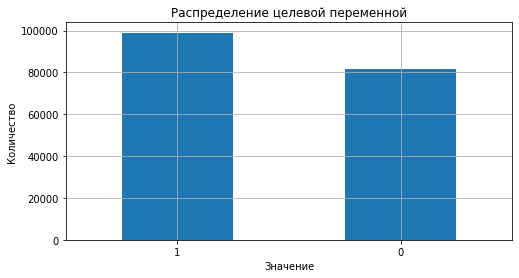

Положительный класс: 54.83%


In [8]:
draw_barplot(df_orders[TARGET].value_counts(), "Распределение целевой переменной", 
             "Значение", "Количество")
print(f"Положительный класс: {df_orders[TARGET].mean() * 100:.2f}%")

- Классы сбалансированы, с задержкой доставляется примерно 55% заказов, как и было указано в постановке задачи.

### 2.2. Анализ географического распределения клиентов
- Построим скаттерплот распределения клиентов по долготе и широте, выделив интересующий нас квадрат.

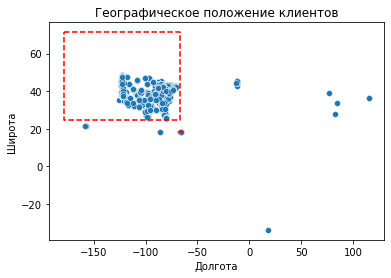

In [9]:
# Границы региона США и Пуэрто-Рико
USA_MIN_LAT = 24.5
USA_MAX_LAT = 71.4
USA_MIN_LONG = -178.2
USA_MAX_LONG = -66.9

PR_MIN_LAT = 17.85
PR_MAX_LAT = 18.53
PR_MIN_LONG = -67.28
PR_MAX_LONG = -65.16

def draw_square(lt, rb, **kwargs):
    x = [lt[0], rb[0], rb[0], lt[0], lt[0]]
    y = [lt[1], lt[1], rb[1], rb[1], lt[1]]
    plt.plot(x, y, **kwargs)

sns.scatterplot(data=df_clients, 
                x='customer_lon',
                y='customer_lat')
plt.title("Географическое положение клиентов")
draw_square(
    (USA_MIN_LONG, USA_MAX_LAT),
    (USA_MAX_LONG, USA_MIN_LAT),
    color='red',
    linestyle='--'
)

draw_square(
    (PR_MIN_LONG, PR_MAX_LAT),
    (PR_MAX_LONG, PR_MIN_LAT),
    color='red',
    linestyle='--'
)

plt.xlabel("Долгота")
plt.ylabel("Широта")
plt.show()

- Удалим клиентов, у которых координаты находятся за пределами интересующего нас региона. Также удалим соответствующие заказы.

In [10]:
clients_count_before_geo = df_clients.shape[0]
orders_count_before_geo = df_orders.shape[0]

df_clients = df_clients[((df_clients['customer_lon'] <= USA_MAX_LONG) &
                        (df_clients['customer_lon'] >= USA_MIN_LONG) &
                        (df_clients['customer_lat'] <= USA_MAX_LAT) & 
                        (df_clients['customer_lat'] >= USA_MIN_LAT)) |
                        ((df_clients['customer_lon'] <= PR_MAX_LONG) &
                        (df_clients['customer_lon'] >= PR_MIN_LONG) &
                        (df_clients['customer_lat'] <= PR_MAX_LAT) & 
                        (df_clients['customer_lat'] >= PR_MIN_LAT))]
df_orders = df_orders[df_orders['customer_id'].isin(df_clients['customer_id'])]

print(f"Удалено клиентов: ", clients_count_before_geo - df_clients.shape[0])
print(f"Удалено заказов: ", orders_count_before_geo - df_orders.shape[0])

Удалено клиентов:  157
Удалено заказов:  1442


### 2.3. Анализ географического распределения целевой переменной

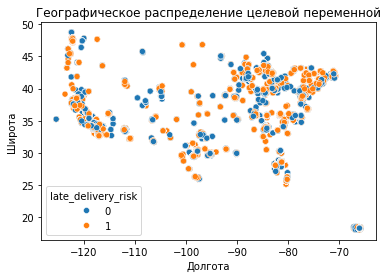

In [11]:
# Объединим таблицы в один датасет
df = df_clients.merge(df_orders, on='customer_id', how='inner')

sns.scatterplot(data=df, 
                x='customer_lon',
                y='customer_lat',
                hue=TARGET)
plt.title("Географическое распределение целевой переменной")
plt.xlabel("Долгота")
plt.ylabel("Широта")
plt.show()

- Предположение о то, что риски доставки связаны с удаленным расположением клиентов оказывается неверным: плотность заказов с задержкой доставки примерно соответствует общей плотности заказов в соответствующем регионе. Высока плотность задержек в густонаселенных регионах с развитой инфраструктурой (Флорида, Калифорния, Нью-Йорк)

### 2.4. Распределение дискретных признаков
- Построим диаграммы распределения категориальных и дискретных признаков в таблице заказов в отношении целевой переменной:

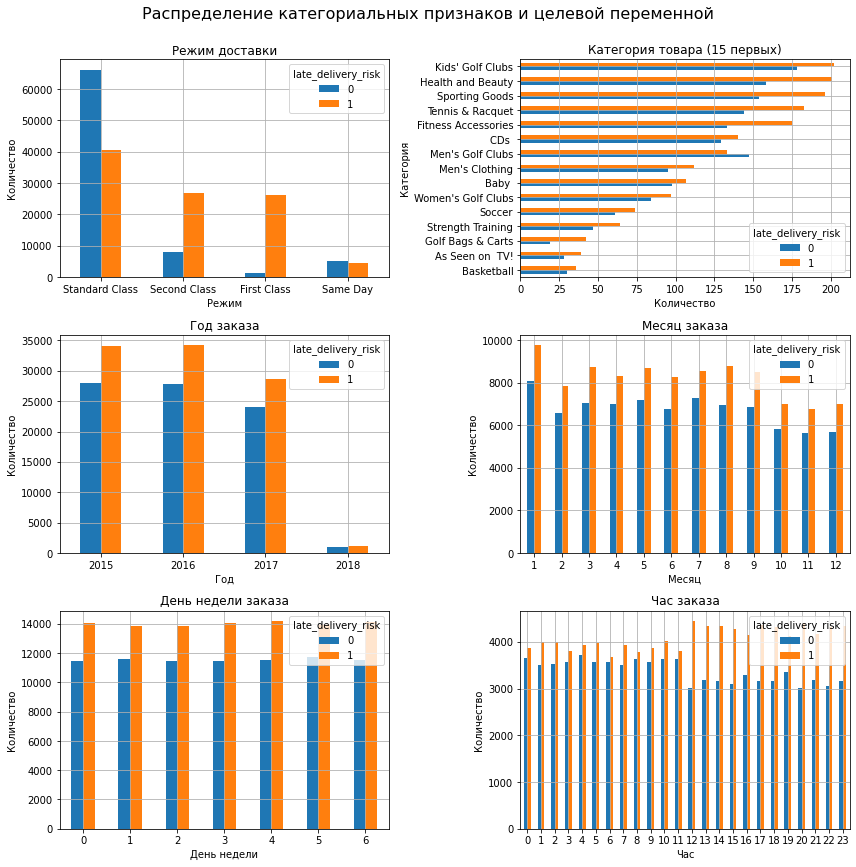

In [12]:
customer_num_features = ['recency', 'total_orders', 'total_sales', 'avg_discount', 'return_rate']
order_num_features = ['item_price', 'order_month', 'order_weekday', 'order_hour']
order_cat_features = ['shipping_mode', 'category_name']

barplot_num_desc = [
    {'data': (df_orders.groupby('shipping_mode')[TARGET]
                        .value_counts()
                        .unstack()
                        .sort_values(by=1, ascending=False)),
     'title': "Режим доставки", 'xlabel': "Режим", 'ylabel': "Количество"},
    {'data': (df_orders
                        .groupby('category_name')[TARGET]
                        .value_counts()
                        .unstack()
                        .sort_values(by=1, ascending=True).head(15)),
     'title': "Категория товара (15 первых)", 'xlabel': "Категория", 'ylabel': "Количество", 'vertical': False},
    {'data': (df_orders
                        .groupby('order_year')[TARGET]
                        .value_counts()
                        .unstack()
                        .sort_values(by='order_year', ascending=True)),
     'title': "Год заказа", 'xlabel': "Год", 'ylabel': "Количество"},
    {'data': (df_orders
                        .groupby('order_month')[TARGET]
                        .value_counts()
                        .unstack()
                        .sort_values(by='order_month', ascending=True)),
     'title': "Месяц заказа", 'xlabel': "Месяц", 'ylabel': "Количество"},
    {'data': (df_orders
                        .groupby('order_weekday')[TARGET]
                        .value_counts()
                        .unstack()
                        .sort_values(by='order_weekday', ascending=True)),
     'title': "День недели заказа", 'xlabel': "День недели", 'ylabel': "Количество"},
    {'data': (df_orders
                        .groupby('order_hour')[TARGET]
                        .value_counts()
                        .unstack()
                        .sort_values(by='order_hour', ascending=True)),
     'title': "Час заказа", 'xlabel': "Час", 'ylabel': "Количество"}
]

show_barplot_grid(barplot_num_desc, "Распределение категориальных признаков и целевой переменной")

- Наибольший риск задержки - у доставки первым и вторым классами (1-2 рабочих дня и 2-5 рабочих дней). Для доставки первым классом риск задержки - почти у всех заказов.
- Вероятно, логистическая компания не справляется с доставками по условиям первого и второго класса - если клиент находится в удалённых локациях, нужно выдавать предупреждение о возможной задержке или ограничивать выбор только стандартным классом.
- Также видна зависимость риска задержки от категории товара. Например, детские клюшки для гольфа доставляются с задержкой более, чем в половине случаев, а взрослые клюшки для гольфа чаще доставляются без задержки. Это может быть связано с распределением разных типов товара по складам, находящимся в разных географических локациях.
- Сведения по заказам представлены за период с 2015 по 2018 год, за 2018 год сведения неполны.
- Присутствуют годовые колебания количества заказов: максимальное количество заказов в январе, минимальное - с октября по декабрь.
- Час размещения заказа тоже связан с количеством заказов и задержек: во вторую половину дня (12-23 часов) количество заказов больше, а для заказов, размещённых в этом временном интервале, риск задержки резко возрастает. Можно предположить, что эти задержки, в основном, относятся к доставке в тот же день или в течение 1 дня (в этом случае остаётся меньше времени на обработку доставки).
- Недельные колебания в количестве заказов отсутствуют - распределение количества заказов по дням недели равномерное.

### 2.5. Распределение числовых признаков

- Построим гистограммы распределения числовых признаков клиентов:

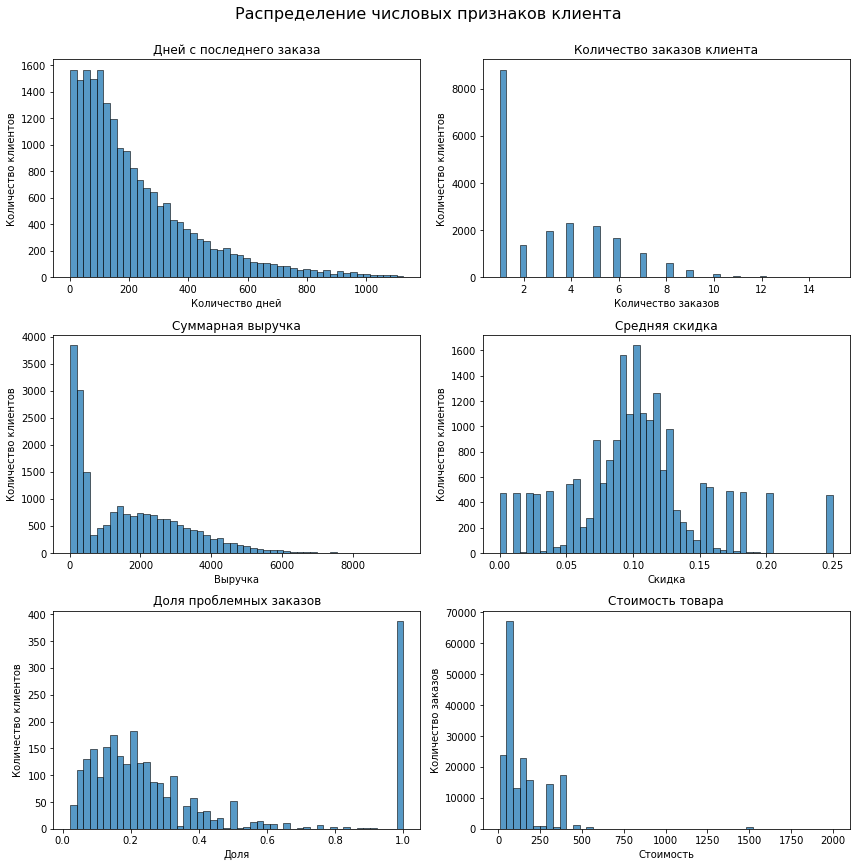

In [13]:
hist_num_desc = [
    {'data': df_clients, 'x': 'recency', 'title': "Дней с последнего заказа",
     'xlabel': "Количество дней", 'ylabel': "Количество клиентов"},
    {'data': df_clients, 'x': 'total_orders', 'title': "Количество заказов клиента",
     'xlabel': "Количество заказов", 'ylabel': "Количество клиентов"},
    {'data': df_clients, 'x': 'total_sales', 'title': "Суммарная выручка",
     'xlabel': "Выручка", 'ylabel': "Количество клиентов"},
    {'data': df_clients, 'x': 'avg_discount', 'title': "Средняя скидка",
     'xlabel': "Скидка", 'ylabel': "Количество клиентов"},
    {'data': df_clients[df_clients['return_rate'] > 0], 'x': 'return_rate', 'title': "Доля проблемных заказов",
     'xlabel': "Доля", 'ylabel': "Количество клиентов"},
    {'data': df_orders, 'x': 'item_price', 'title': "Стоимость товара",
     'xlabel': "Стоимость", 'ylabel': "Количество заказов", 'hue': TARGET},
]

show_histogram_grid(hist_num_desc, "Распределение числовых признаков клиента", bins=50)

- Аномалии в числовых признаках отсутствуют.
- Большинство клиентов разместили по одному заказу. Максимальное количество прочих клиентов разместили по 4 заказа.
- Наибольшее количество клиентов имеет долю проблемных заказов 100%. По всей видимости, это клиенты, разместившие всего один заказ, с доставкой которого возникли проблемы. Фактически эти клиенты были потеряны из-за неправильно спланированной логистики.

### 2.6. Анализ корреляций
- Соединим таблицы по `customer_id`:

In [14]:
num_features = order_num_features + customer_num_features
cat_features = order_cat_features

- Построим матрицу корреляций

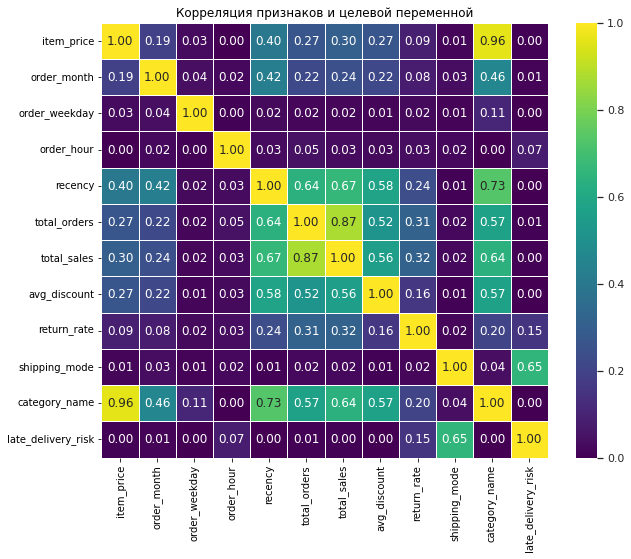

In [15]:
phik_matrix = phik.phik_matrix(df[num_features + cat_features + [TARGET]], interval_cols=num_features)
draw_heatmap(phik_matrix, "Корреляция признаков и целевой переменной", figsize=(10, 8), font_scale=1)

- Признаки клиента довольно сильно коррелируют друг с другом. Вполне ожидаема связь между количеством заказов, суммарной выручкой, скидкой и частотой заказов.
- Признаки клиента также сильно коррелируют с категорией товара, что указывает на одинаковые паттерны поведения клиентов, покупающих схожие товары.
- Целевая переменная более всего коррелирует с режимом доставки, также присутствует слабая корреляция с долей проблемных заказов и часом размещения заказа.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

* связанные заказы удаляются вместе с исключенными клиентами

* Проанализированы категориальные, временные и числовые признаки

* Для смешанных типов данных использована PhiK-корреляция

## 3. Разделение датасета на выборки
### 3.1. Выделение обучающей, валидационной и тестовой выборок

In [16]:
groups = df_orders['customer_id']

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_SEED)
train_val_idx, test_idx = next(gss1.split(df_orders, groups=groups))
X_test, y_test = (df_orders.iloc[test_idx].drop(columns=[TARGET]), 
                  df_orders[TARGET].iloc[test_idx])

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_SEED)
df_train_val = df_orders.iloc[train_val_idx]
groups2 = df_train_val['customer_id']
train_idx, val_idx = next(gss2.split(df_train_val, groups=groups2))
X_train, y_train = (df_train_val.iloc[train_idx].drop(columns=[TARGET]), 
                    df_train_val[TARGET].iloc[train_idx])
X_val, y_val = (df_train_val.iloc[val_idx].drop(columns=[TARGET]), 
                df_train_val[TARGET].iloc[val_idx])

display(HTML("<h3>Размеры выборок<h3>"), 
        pd.Series({"Train": X_train.shape[0],
                    "Validation": X_val.shape[0],
                    "Test": X_test.shape[0]}))

display(HTML("<h3>Проверка корректности разделения</h3>"))

print("Общих customer_id в train и val:", 
      X_train[X_train['customer_id'].isin(X_val['customer_id'])].shape[0])
print("Общих customer_id в train и test:", 
      X_train[X_train['customer_id'].isin(X_test['customer_id'])].shape[0])
print("Общих customer_id в val и test:", 
      X_val[X_val['customer_id'].isin(X_test['customer_id'])].shape[0])

# Сохраним идентификаторы клиентов из каждой выборки для использования в дальнейшем
train_customer_ids = X_train['customer_id']
val_customer_ids = X_val['customer_id']
test_customer_id = X_test['customer_id']

X_train.info()

Train         107125
Validation     35912
Test           36035
dtype: int64

Общих customer_id в train и val: 0
Общих customer_id в train и test: 0
Общих customer_id в val и test: 0
<class 'pandas.core.frame.DataFrame'>
Index: 107125 entries, 1 to 180516
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   order_id       107125 non-null  int64         
 1   customer_id    107125 non-null  int64         
 2   shipping_mode  107125 non-null  object        
 3   category_name  107125 non-null  object        
 4   order_date     107125 non-null  datetime64[ns]
 5   item_price     107125 non-null  float64       
 6   order_year     107125 non-null  int32         
 7   order_month    107125 non-null  int32         
 8   order_weekday  107125 non-null  int32         
 9   order_hour     107125 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(4), int64(2), object(2)
memory usage: 7.4+ MB


### 3.2. Выводы:
- Датасет разделён на обучающую, валидационную и тестовую выборки в отношении 3:1:1.
- Данные по каждому клиенту целиком вошли в одну из выборок, разделение выполнено корректно.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Идентификаторы клиентов сохранены для дальнейших этапов

## 4. Обучение базовых моделей
### 4.1. Создание пайплайна предобработки
- Для логистической регрессии закодируем категориальные признаки при помощи One Hot Encoding, числовые признаки масштабируем при помощи `StandardScaler`
- Для `CatBoostClassifier` оставим признаки без изменений.

In [17]:
base_preprocess_pp = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), order_cat_features),
    ('num', StandardScaler(), order_num_features)
])

cb_preprocess_pp = ColumnTransformer(transformers=[
    ('restrict', 'passthrough', order_cat_features + order_num_features)
], verbose_feature_names_out=False).set_output(transform='pandas')

# Функция для вычисления необходимых метрик
def calc_metrics(y, y_pred_proba, threshold=0.5, prefix=''):
    y_pred = y_pred_proba >= threshold
    return pd.Series({prefix + 'accuracy': accuracy_score(y, y_pred),
                    prefix + 'precision': precision_score(y, y_pred),
                    prefix + 'recall': recall_score(y, y_pred),
                    prefix + 'f1': f1_score(y, y_pred),
                    prefix + 'ROC-AUC': roc_auc_score(y, y_pred_proba)
                    })

### 4.2. Обучение базовой модели `LogisticRegression`

In [18]:
base_lr_pipe = Pipeline([
    ('pp', clone(base_preprocess_pp)),
    ('model', LogisticRegression(random_state=RANDOM_SEED))
])

base_lr_pipe.fit(X_train, y_train)
y_lr_base_pred = base_lr_pipe.predict_proba(X_val)[:, 1]
base_lr_metrics = calc_metrics(y_val, y_lr_base_pred)
display(base_lr_metrics)
print(classification_report(y_val, y_lr_base_pred >= BASE_THRESHOLD))

accuracy    0.6875
precision   0.8415
recall      0.5363
f1          0.6551
ROC-AUC     0.7216
dtype: float64

              precision    recall  f1-score   support

           0       0.60      0.87      0.71     16038
           1       0.84      0.54      0.66     19874

    accuracy                           0.69     35912
   macro avg       0.72      0.71      0.68     35912
weighted avg       0.74      0.69      0.68     35912



### 4.3. Обучение базовой модели `CatBoostClassifier`

In [19]:
base_cb_pipe = Pipeline([
    ('pp', clone(cb_preprocess_pp)),
    ('model', CatBoostClassifier(random_state=RANDOM_SEED, 
                                 verbose=False, 
                                 cat_features=order_cat_features))
])

base_cb_pipe.fit(X_train, y_train)
y_cb_base_pred = base_cb_pipe.predict_proba(X_val)[:, 1]
base_cb_metrics = calc_metrics(y_val, y_cb_base_pred)
display(base_cb_metrics)
print(classification_report(y_val, y_cb_base_pred >= BASE_THRESHOLD))

accuracy    0.7088
precision   0.8428
recall      0.5825
f1          0.6889
ROC-AUC     0.7459
dtype: float64

              precision    recall  f1-score   support

           0       0.63      0.87      0.73     16038
           1       0.84      0.58      0.69     19874

    accuracy                           0.71     35912
   macro avg       0.73      0.72      0.71     35912
weighted avg       0.75      0.71      0.71     35912



### 4.4. Сравнение результатов

In [20]:
display(pd.DataFrame({
    "Base LR": base_lr_metrics,
    "Base CB": base_cb_metrics
}))

,Base LR,Base CB
accuracy,0.6875,0.7088
precision,0.8415,0.8428
recall,0.5363,0.5825
f1,0.6551,0.6889
ROC-AUC,0.7216,0.7459


- `CatBoostClassifier` показывает лучшие результаты по всем метрикам, чем `LogisticRegression`, однако её результаты все равно ниже требуемого уровня 0.75 для ROC-AUC.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

* ROC-AUC рассчитывается по вероятностям

* Baseline оценивается на validation

## 5. Кластеризация записей о клиентах
### 5.1. Кластеризация по географическим признакам
- Для предотвращения утечки данных будем проводить кластеризацию только для клиентов из обучающей выборки.

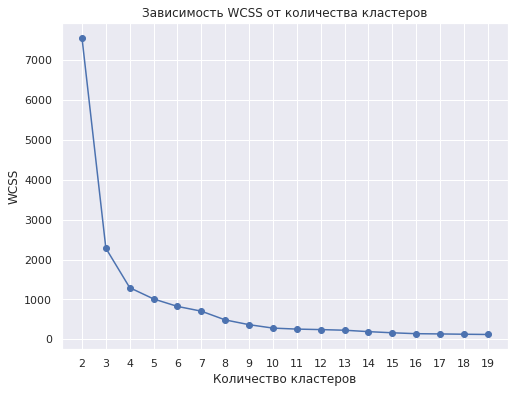

In [21]:
geo_features = ['customer_lat', 'customer_lon']
df_clients_train = df_clients[df_clients['customer_id'].isin(train_customer_ids)]

def elbow_graph(pp_pipeline, k_range, X):
    wcss = []
    pps = {}

    for k in k_range:
        pp = Pipeline([
            ('pp', clone(pp_pipeline)),
            ('kmeans', KMeans(n_clusters=k, random_state=RANDOM_SEED))
        ])
        pp.fit(X)
        pps[k] = pp
        wcss.append(pp.named_steps['kmeans'].inertia_)

    # График локтя
    plt.figure(figsize=(8, 6))
    plt.plot(list(k_range), wcss, marker="o")
    plt.xticks(list(k_range))
    plt.xlabel("Количество кластеров")
    plt.ylabel("WCSS")
    plt.title("Зависимость WCSS от количества кластеров")
    plt.grid(True)
    plt.show()

    return pps
    
geo_pps = elbow_graph(ColumnTransformer([
                ('geo', StandardScaler(), geo_features)
            ], remainder='drop'), range(2, 20), df_clients_train);

- Оптимальное количество кластеров - 4
- Отобразим кластеры на скаттерплоте:

/tmp/ipykernel_85/1209779113.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clients_train['geo_cluster'] = geo_pps[N_GEO_CLUSTERS].predict(df_clients_train)


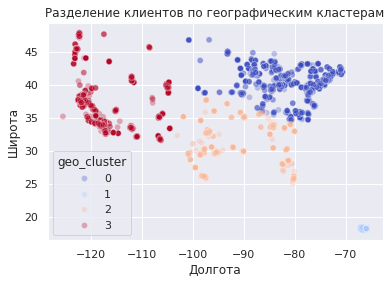

In [22]:
N_GEO_CLUSTERS = 4

df_clients_train['geo_cluster'] = geo_pps[N_GEO_CLUSTERS].predict(df_clients_train)

draw_scatterplot(df_clients_train, 
                 'customer_lon', 
                 'customer_lat', 
                 "Разделение клиентов по географическим кластерам",
                 "Долгота",
                 "Широта",
                 hue='geo_cluster',
                 palette='coolwarm',
                 alpha=0.3
                 )

- 4 географических кластера:
    - Северо-восток
    - Пуэрто-Рико
    - Юго-восток
    - Западное побережье

### 5.2. Кластеризация по признакам профилей клиентов

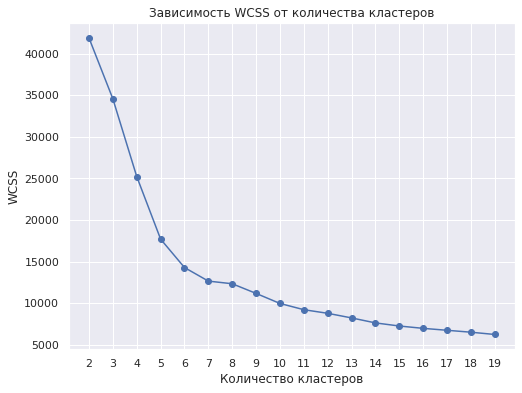

In [23]:
profile_features = ['recency', 'total_orders', 'total_sales', 'return_rate', 'avg_discount']

scaler = ColumnTransformer([
                ('profile', StandardScaler(), profile_features)
            ], remainder='drop')
prof_pps = elbow_graph(scaler, range(2, 20), df_clients_train);

- Оптимальное количество кластеров - 7
- Визуализируем кластеры при помощи t-SNE

In [24]:
N_BEH_CLUSTERS = 7

df_clients_train['beh_cluster'] = prof_pps[N_BEH_CLUSTERS].predict(df_clients_train)

tsne = TSNE(
    n_components=2,
    perplexity=50,
    init="pca",
    random_state=RANDOM_SEED,
    learning_rate="auto"
)

df_clients_tsne = tsne.fit_transform(scaler.fit_transform(df_clients_train))

/tmp/ipykernel_85/2749078766.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clients_train['beh_cluster'] = prof_pps[N_BEH_CLUSTERS].predict(df_clients_train)


/tmp/ipykernel_85/3127422437.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clients_train[['tsne_1', 'tsne_2']] = df_clients_tsne
/tmp/ipykernel_85/3127422437.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clients_train[['tsne_1', 'tsne_2']] = df_clients_tsne


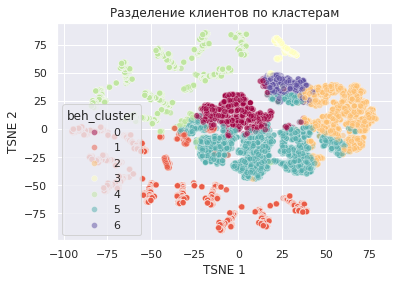

In [25]:
df_clients_train[['tsne_1', 'tsne_2']] = df_clients_tsne
draw_scatterplot(df_clients_train, 
                 'tsne_1', 
                 'tsne_2', 
                 "Разделение клиентов по кластерам", 
                 "TSNE 1", 
                 "TSNE 2", 
                 hue='beh_cluster', 
                 palette='Spectral',
                 alpha=0.5)

- Построим диаграмму отклонения признаков от среднего по кластерам для их интерпретации:

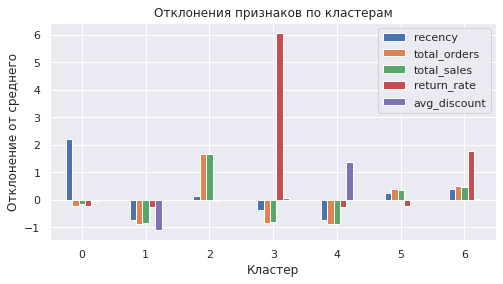

In [26]:
cluster_means = df_clients_train.groupby('beh_cluster')[profile_features].mean()
means = df_clients_train[profile_features].mean()
stds = df_clients_train[profile_features].std()

cluster_profile_means = (cluster_means - means) / stds

draw_barplot(cluster_profile_means, "Отклонения признаков по кластерам", "Кластер", "Отклонение от среднего")

- Кластеры разделены достаточно хорошо. Пересечений на t-SNE диаграмме мало.
- По отклонениям признаков можно предположить, что кластеры имеют такой смысл:

    0. Клиенты, редко размещающие заказы.
    1. Клиенты, сделавшие один заказ на небольшую сумму. Выручка от них минимальна.
    2. Клиенты, сделавшие максимальное число заказов и принесшие наибольшую выручку.
    3. Клиенты, чаще всего оформляющие возврат. Наиболее проблемная категория.
    4. Клиенты с таким же профилем, как в кластере 1, но с большой скидкой. Вероятно, реагируют на акции и делают заказ только в случае больших скидок.
    5. Клиенты со средними показателями по всем параметрам.
    6. Клиенты, похожие на группу 5, но часто оформляющие возврат.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Для поведенческой сегментации использованы все пять требуемых признаков

## 6. Обучение моделей на расширенном наборе признаков
### 6.1. Подготовка данных и пайплайнов

In [27]:
# Трансформер для добавления признаков с метками кластеров
class ClusterLabelTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, features, label_name, n_clusters):
        self.features = features
        self.n_clusters = n_clusters
        self.label_name = label_name

    def fit(self, X, y=None):
        self.pipeline_ = Pipeline([
            ('scale', StandardScaler()),
            ('kmeans', KMeans(n_clusters=self.n_clusters, random_state=RANDOM_SEED))
        ])
        self.pipeline_.fit(X.drop_duplicates('customer_id')[self.features])
        return self

    def transform(self, X):
        X_new = X.copy()
        X_new[self.label_name] = self.pipeline_.predict(X[self.features])
        return X_new

def make_cluster_pp(n_geo_clusters, n_beh_clusters):
    return Pipeline([
        ('geo_labels', ClusterLabelTransformer(geo_features, 
                                            'geo_cluster',
                                            n_geo_clusters)),
        ('beh_labels', ClusterLabelTransformer(profile_features, 
                                            'beh_cluster',
                                            n_beh_clusters))
    ])

# Соединение выборок с данными о клиентах
X_train_ext = X_train.merge(df_clients, on='customer_id', how='inner')
X_val_ext = X_val.merge(df_clients, on='customer_id', how='inner')
X_test_ext = X_test.merge(df_clients, on='customer_id', how='inner')

### 6.2. Обучение `LogisticRegression`

In [28]:
lr_pp = Pipeline([
    ('f_eng', make_cluster_pp(N_GEO_CLUSTERS, N_BEH_CLUSTERS)), 
    ('scale_ohe', ColumnTransformer([
        ('num', StandardScaler(), order_num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), 
         cat_features + ['geo_cluster', 'beh_cluster'])
    ])),
    ('model', LogisticRegression(random_state=RANDOM_SEED))
])

lr_pp.fit(X_train_ext, y_train)
y_val_lr_pred_ext = lr_pp.predict_proba(X_val_ext)[:, 1]

ext_lr_metrics = calc_metrics(y_val, y_val_lr_pred_ext)
display(pd.DataFrame({"Base LR": base_lr_metrics,
                     "Ext LR": ext_lr_metrics}))

,Base LR,Ext LR
accuracy,0.6875,0.6914
precision,0.8415,0.8444
recall,0.5363,0.5424
f1,0.6551,0.6605
ROC-AUC,0.7216,0.7291


- Логистическая регрессия на расширенном наборе признаков даёт лучшие результаты по всем метрикам, но метрика ROC-AUC все равно ниже требуемого значения 0.75.

### 6.3. Обучение `CatBoostClassifier`

In [29]:
def make_cb_preprocess(n_geo_clusters, n_beh_clusters):
    return Pipeline([
        ('f_eng', make_cluster_pp(n_geo_clusters, n_beh_clusters)),
        ('restrict', ColumnTransformer(
            transformers=[
                ('restrict', 'passthrough', num_features + cat_features + ['geo_cluster', 'beh_cluster'])
            ], 
            verbose_feature_names_out=False)
            .set_output(transform='pandas'))
    ])

def make_cb_pipeline(n_geo_clusters, n_beh_clusters, **params):
    cb_pp = Pipeline([
        ('f_eng', make_cluster_pp(n_geo_clusters, n_beh_clusters)),
        ('restrict', ColumnTransformer(
            transformers=[
                ('restrict', 'passthrough', num_features + cat_features + ['geo_cluster', 'beh_cluster'])
            ], 
            verbose_feature_names_out=False)
            .set_output(transform='pandas')),
        ('model', CatBoostClassifier(cat_features=cat_features + ['geo_cluster', 'beh_cluster'],
                                    random_seed=RANDOM_SEED, verbose=False, **params))
    ])
    
    return cb_pp

cb_pp = make_cb_pipeline(N_GEO_CLUSTERS, N_BEH_CLUSTERS)

cb_pp.fit(X_train_ext, y_train)
y_val_cb_pred_ext = cb_pp.predict_proba(X_val_ext)[:, 1]

ext_cb_metrics = calc_metrics(y_val, y_val_cb_pred_ext)
display(pd.DataFrame({"Base CB": base_cb_metrics,
                     "Ext CB": ext_cb_metrics}))

,Base CB,Ext CB
accuracy,0.7088,0.7024
precision,0.8428,0.8053
recall,0.5825,0.6096
f1,0.6889,0.6939
ROC-AUC,0.7459,0.7658


- `CatBoostClassifier` значительно улучшил метрику ROC-AUC на расширенном наборе признаков: получено значение, превышающее требуемый показатель 0.75.
- Возможно, удастся улучшить результаты при помощи подбора гиперпараметров. 

### 6.4. Подбор гиперпараметров `CatBoostClassifier`

In [30]:
def objective_cb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'depth': trial.suggest_int('depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 100),
        'rsm': trial.suggest_float('rsm', 0.3, 1)
    }

    n_geo_clusters = trial.suggest_int('n_geo_clusters', 2, 20)
    n_beh_clusters = trial.suggest_int('n_beh_clusters', 3, 40)

    cb_pp = make_cb_pipeline(n_geo_clusters, n_beh_clusters, **params)

    cb_pp.fit(X_train_ext, y_train)
    roc_auc = roc_auc_score(y_val, cb_pp.predict_proba(X_val_ext)[:, 1])
    trial.report(roc_auc, step=0)

    if trial.should_prune():
        raise optuna.TrialPruned() 

    return roc_auc

sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)

cb_study = optuna.create_study(direction="maximize", sampler=sampler) 
cb_study.optimize(objective_cb, n_trials=25, show_progress_bar=True) 

display(HTML("<h2>Лучшие гиперпараметры:</h2>"))
display(pd.Series(cb_study.best_params))
display(HTML(f"<h2>Лучшее значение ROC-AUC: </h2>{cb_study.best_value:8f}"))

[I 2026-07-24 10:22:12,708] A new study created in memory with name: no-name-9b65e847-ef54-4eac-99e8-2b92928e6937


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-07-24 10:26:02,627] Trial 0 finished with value: 0.746767820019584 and parameters: {'n_estimators': 1062, 'depth': 10, 'learning_rate': 0.29106359131330695, 'l2_leaf_reg': 6.387926357773329, 'min_data_in_leaf': 19, 'rsm': 0.40919616423534183, 'n_geo_clusters': 3, 'n_beh_clusters': 35}. Best is trial 0 with value: 0.746767820019584.
[I 2026-07-24 10:29:02,544] Trial 1 finished with value: 0.7686575114579878 and parameters: {'n_estimators': 1402, 'depth': 8, 'learning_rate': 0.010994335574766204, 'l2_leaf_reg': 9.72918866945795, 'min_data_in_leaf': 84, 'rsm': 0.44863737747479326, 'n_geo_clusters': 5, 'n_beh_clusters': 9}. Best is trial 1 with value: 0.7686575114579878.
[I 2026-07-24 10:30:48,565] Trial 2 finished with value: 0.7643093235105318 and parameters: {'n_estimators': 956, 'depth': 7, 'learning_rate': 0.0730953983591291, 'l2_leaf_reg': 3.6210622617823773, 'min_data_in_leaf': 63, 'rsm': 0.3976457024564293, 'n_geo_clusters': 7, 'n_beh_clusters': 16}. Best is trial 1 with va

n_estimators       840.0000
depth                3.0000
learning_rate        0.0214
l2_leaf_reg          2.0078
min_data_in_leaf    57.0000
rsm                  0.5194
n_geo_clusters      17.0000
n_beh_clusters      15.0000
dtype: float64

### 6.5. Выводы
- Добавление новых признаков привело к повышению качества обучения моделей, метрика ROC-AUC увеличилась. 
- Модель `CatBoostClassifier` показала значение ROC-AUC 0.7686, с помощью подбора гиперпараметров это значение удалось увеличить до 0.772; эти значения удовлетворяют требованиям задачи (ROC-AUC > 0.75).
- Количество кластеров в оптимальном наборе параметров оказалось значительно больше, чем вычисленное при помощи метода локтя. Вероятно, меньшее количество кластеров не вполне отражает скрытые зависимости.

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

В ClusterLabelTransformer KMeans обучается на объединенной таблице заказов:

    self.pipeline_.fit(X[self.features])

X_train_ext содержит несколько строк для одного клиента - по одной на каждый заказ. Поэтому клиент с десятью заказами участвует в кластеризации десять раз, а клиент с одним заказом - один раз. Это не клиентская сегментация с равным весом каждого клиента. Результат зависит от количества заказов и не соответствует логике кластеризации профилей.

Нужно обучать scaler и KMeans на уникальных клиентах:

    clients = X[
        ['customer_id'] + self.features
    ].drop_duplicates('customer_id')

После обучения нужно получить соответствие customer_id -> cluster и присоединить метки обратно ко всем заказам. Тот же принцип должен использоваться:

    в LogisticRegression
    в CatBoost
    внутри Optuna
    при финальном обучении на train + validation

После исправления нужно заново пересчитать расширенные модели, Optuna и финальную тестовую метрику

## 7. Тестирование модели
### 7.1. Получение предсказания на тестовой выборке

In [31]:
best_params = cb_study.best_params
n_geo_clusters = best_params.pop('n_geo_clusters')
n_beh_clusters = best_params.pop('n_beh_clusters')

final_cb_pp = make_cb_pipeline(n_geo_clusters, n_beh_clusters, **best_params)

X_train_val_ext = pd.concat([X_train_ext, X_val_ext])
y_train_val = pd.concat([y_train, y_val])

final_cb_pp.fit(X_train_val_ext, y_train_val)
y_final_pred_test = final_cb_pp.predict_proba(X_test_ext)[:, 1]

display(calc_metrics(y_test, y_final_pred_test))

accuracy    0.7165
precision   0.8590
recall      0.5814
f1          0.6935
ROC-AUC     0.7747
dtype: float64

- Метрика ROC-AUC удовлетворяет требованиям задания.
- Баланс оценок смещён в сторону точности в ущерб полноте.

### 7.2. Построение матрицы ошибок

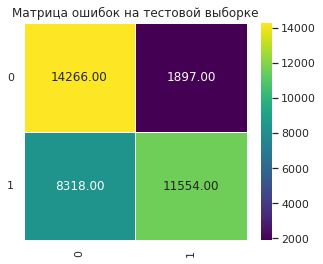

In [32]:
threshold = 0.5
conf_matrix = confusion_matrix(y_test, y_final_pred_test >= threshold)
draw_heatmap(conf_matrix, "Матрица ошибок на тестовой выборке", figsize=(5, 4), font_scale=1)

- Модель имеет высокую точность (precision), но часто пропускает задержки. Можно подобрать значение порога, чтобы улучшить баланс precision/recall.

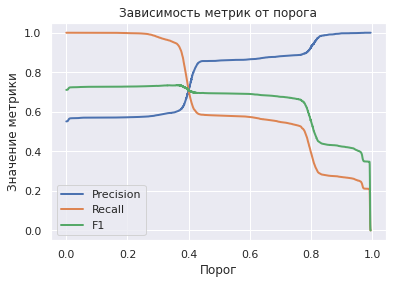

In [33]:
pr_curve = precision_recall_curve(y_test, y_final_pred_test)
f1_curve = 2 * pr_curve[0] * pr_curve[1] / (pr_curve[0] + pr_curve[1])

plt.plot(pr_curve[2], pr_curve[0][:-1], label="Precision", linewidth=2)
plt.plot(pr_curve[2], pr_curve[1][:-1], label="Recall", linewidth=2)
plt.plot(pr_curve[2], f1_curve[:-1], label="F1", linewidth=2)
plt.legend()
plt.title("Зависимость метрик от порога")
plt.xlabel("Порог")
plt.ylabel("Значение метрики")
plt.show()

- Оптимальное значение порога - 0.4.

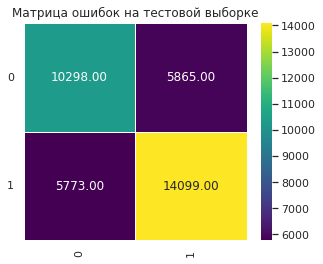

accuracy    0.6770
precision   0.7062
recall      0.7095
f1          0.7079
ROC-AUC     0.7747
dtype: float64

In [34]:
threshold = 0.4
conf_matrix = confusion_matrix(y_test, y_final_pred_test >= threshold)
draw_heatmap(conf_matrix, "Матрица ошибок на тестовой выборке", figsize=(5, 4), font_scale=1)
display(calc_metrics(y_test, y_final_pred_test, 0.4))

- Значения Precision и Recall получились более сбалансированными; F1 увеличилась, но немного уменьшилась Accuracy.

### 7.3. Оценка важности признаков при помощи `feature_importances`

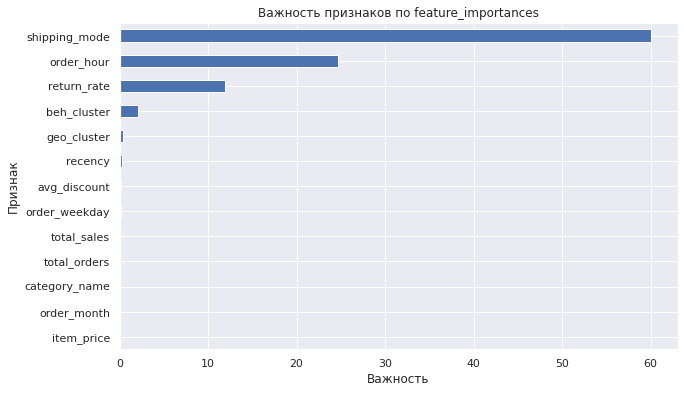

In [35]:
model = final_cb_pp.named_steps['model']
feat_names = final_cb_pp.named_steps['restrict'].get_feature_names_out()
fi = model.feature_importances_

fi_ser = pd.Series(fi, index=feat_names)

draw_barplot(fi_ser.sort_values(ascending=True).tail(20), 
             "Важность признаков по feature_importances", 
             "Признак", 
             "Важность",
             figsize=(10, 6),
             vertical=False)

### 7.4. Оценка важности признаков при помощи SHAP

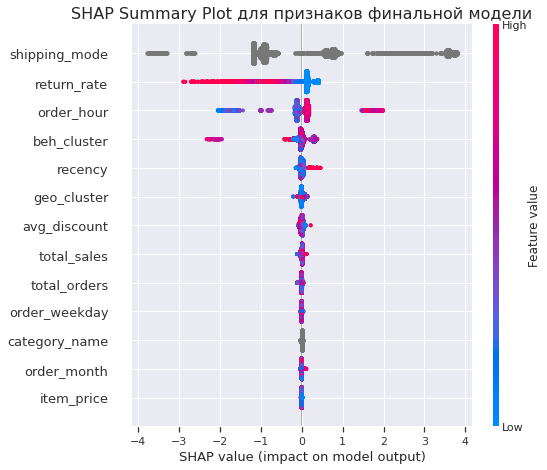

In [36]:
explainer = shap.TreeExplainer(model)
cb_preprocess = make_cb_preprocess(n_geo_clusters, n_beh_clusters)
cb_preprocess.fit(X_train_val_ext, y_train_val)
X_test_pp = cb_preprocess.transform(X_test_ext)
cb_shap = explainer.shap_values(X_test_pp)

plt.figure(figsize=(10, 8))
shap.summary_plot(cb_shap, X_test_pp, show=False, max_display=40)
plt.title("SHAP Summary Plot для признаков финальной модели", fontsize=16)
plt.tight_layout()
plt.show()

### 7.5. Выводы
- Модель, обученная на объединённой обучающей и валидационной выборке, показывает значение метрики ROC-AUC, превышающее 0.75. Модель удовлетворяет сформулированным требованиям.
- Со значением порога по умолчанию модель имеет высокую точность (precision), но часто пропускает задержки, было подобрано значение порога 0.4, при котором увеличилась метрика F1, а Precision и Recall получились более сбалансированными.
- Оба метода анализа важности признаков дали одинаковые результаты. Наиболее важными признаками оказались режим доставки, час создания заказа, доля возвратов. Это подтверждает выводы, сделанные на этапе EDA: 
    - Заказы с первым классом или вторым доставки почти всегда задерживаются.
    - Часто задерживаются заказы, сделанные во второй половине дня.
- Метки кластеров по важности занимают следующую позицию. Кластер профиля клиента оказывает большее влияние на оценку, чем кластер географического положения, что еще раз подтверждает неверность выводов департамента логистики об удалённости клиента как наиболее важной причине задержек доставки.

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

Поправь, пожалуйста, выводы после корректировки

## 8. Выводы по проекту
### 8.1. Общие сведения
- Для обучения модели были представлены сведения о 20652 клиентах и 180519 заказах.
- Пропусков в данных не обнаружено.
- Найдено 5 дублирующихся клиентов с 5 заказами. Дубликаты удалены.
- Классы целевой переменной сбалансированы, с задержкой доставляется примерно 55% заказов, как и было указано в постановке задачи.
- Были удалены клиенты и заказы с ошибочными координатами (за пределами США и Пуэрто-Рико).
### 8.2. Результаты исследовательского анализа данных
- Было проанализировано географическое распределение заказов с задержкой доставки. Предположение о то, что риски доставки связаны с удаленным расположением клиентов оказывается неверным: плотность заказов с задержкой доставки примерно соответствует общей плотности заказов в соответствующем регионе. Высока плотность задержек в густонаселенных регионах с развитой инфраструктурой (Флорида, Калифорния, Нью-Йорк).

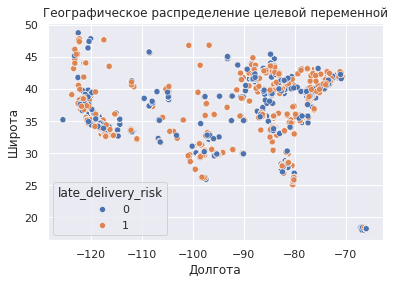

In [37]:
sns.scatterplot(data=df, 
                x='customer_lon',
                y='customer_lat',
                hue=TARGET)
plt.title("Географическое распределение целевой переменной")
plt.xlabel("Долгота")
plt.ylabel("Широта")
plt.show()

- Наибольший риск задержки - у доставки первым и вторым классами (1-2 рабочих дня и 2-5 рабочих дней). Для доставки первым классом риск задержки - почти у всех заказов.
- Вероятно, логистическая компания не справляется с доставками по условиям первого и второго класса - если клиент находится в удалённых локациях, следует выдавать предупреждение о возможной задержке или ограничивать выбор только стандартным классом.
- Также видна зависимость риска задержки от категории товара. Например, детские клюшки для гольфа доставляются с задержкой более, чем в половине случаев, а взрослые клюшки для гольфа чаще доставляются без задержки. Это может быть связано с распределением разных типов товара по складам, находящимся в разных географических локациях.
- Присутствуют годовые колебания количества заказов: максимальное количество заказов в январе, минимальное - с октября по декабрь.
- Час размещения заказа тоже связан с количеством заказов и задержек: во вторую половину дня (12-23 часов) количество заказов больше, а для заказов, размещённых в этом временном интервале, риск задержки резко возрастает. Можно предположить, что эти задержки, в основном, относятся к доставке в тот же день или в течение 1 дня (в этом случае остаётся меньше времени на обработку доставки).
- Недельные колебания в количестве заказов отсутствуют - распределение количества заказов по дням недели равномерное.
- Большинство клиентов разместили по одному заказу. Максимальное количество прочих клиентов разместили по 4 заказа.
- Наибольшее количество клиентов имеет долю проблемных заказов 100%. По всей видимости, это клиенты, разместившие всего один заказ, с доставкой которого возникли проблемы. Фактически эти клиенты были потеряны из-за неправильно спланированной логистики.
- Признаки клиента довольно сильно коррелируют друг с другом. Вполне ожидаема связь между количеством заказов, суммарной выручкой, скидкой и частотой заказов.
- Признаки клиента также сильно коррелируют с категорией товара, что указывает на одинаковые паттерны поведения клиентов, покупающих схожие товары.
- Целевая переменная более всего коррелирует с режимом доставки, также присутствует слабая корреляция с долей проблемных заказов и часом размещения заказа.
### 8.3. Результаты обучения базовых моделей
- На данных о заказах были обучены модели логистической регрессии и градиентного бустинга `CatBoostClassifier`.
- Модель градиентного бустинга показала лучший результат, чем логистическая регрессия, однако метрика ROC-AUC оказалась ниже требуемой.
### 8.4. Кластеризация данных о клиентах и добавление новых признаков
- В данных о клиентах были выделены кластеры по следующим признакам:
    - Географические координаты;
    - Признаки профиля клиента (`recency`, `total_orders`, `total_sales`, `return_rate` и `avg_discount`)
- При помощи метода локтя было установлено оптимальное количество кластеров (4 и 7)
- Метки кластеров были добавлены в качестве новых признаков для обучения моделей.
### 8.5. Обучение моделей на расширенном наборе признаков
- На данных, дополненных признаками клиента и метками кластеров, были обучены модели логистической регрессии и градиентного бустинга `CatBoostClassifier`.
- Полученные значения метрик оказались выше, чем у базовых моделей. Метрика ROC-AUC у модели `CatBoostClassifier` удовлетворяет требованиям задания (>0.75).
- Для модели `CatBoostClassifier` был организован подбор гиперпараметров при помощи библиотеки Optuna. Кроме параметров градиентного бустинга подбиралось количество кластеров. На оптимальном наборе гиперпараметров модель показала лучшие значения метрик, чем с параметрами по умолчанию, причем количество кластеров оказалось значительно больше, чем выбранное методом локтя (17 геокластеров и 16 кластеров по профилям клиентов). Это указывает на то, что в данных присутствуют более сложные зависимости, которые не удалось найти на предыдущих этапах.
### 8.6. Тестирование модели
- Модель `CatBoostClassifier` с оптимальными гиперпараметрами была обучена на объединённой обучающей и валидационной выборке и протестирована на тестовой выборке. Полученные значения метрик удовлетворяют требованиям задания.
- Анализ кривой precision/recall показал, что оптимальным значением порога положительного класса является 0.4.
- Анализ значимости признаков был проведён методами `feature_importances` и SHAP. Оба метода дали одинаковые результаты. Наиболее важными признаками оказались режим доставки, час создания заказа, доля возвратов. Это подтверждает выводы, сделанные на этапе EDA: 
    - Заказы с первым классом или вторым доставки почти всегда задерживаются.
    - Часто задерживаются заказы, сделанные во второй половине дня.
- Метки кластеров по важности занимают следующую позицию. Кластер профиля клиента оказывает большее влияние на оценку, чем кластер географического положения, что еще раз подтверждает неверность выводов департамента логистики об удалённости клиента как наиболее важной причине задержек доставки.
### 8.7. Рекомендации
- Анализ данных показал, что у компании есть проблемы в организации логистики - доставка задерживается более, чем у половины заказов, причём задержки не связаны с удалённым расположением клиентов. 
- Для прогнозирования задержек можно использовать предложенную модель, которая на основании сведений о заказе и профиле клиента с вероятностью 0.72 (метрика precision) укажет на риск задержки доставки. Для таких заказов можно сменить приоритет доставки, уточнить намерения клиента или предупредить о возможной задержке в зависимости от параметров профиля клиента.
- Следует иметь в виду, что метрика Recall у модели 0.67, то есть модель будет определять около 2/3 возможных задержек. Баланс между точностью и полнотой выявления риска задержек можно регулировать путем указания разных значений порога положительного класса на основании следующей диаграммы:

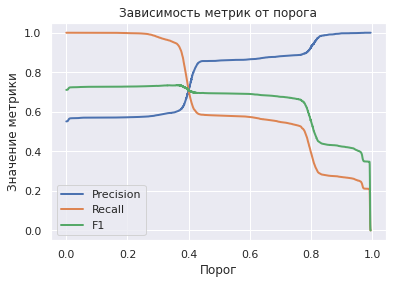

In [38]:
plt.plot(pr_curve[2], pr_curve[0][:-1], label="Precision", linewidth=2)
plt.plot(pr_curve[2], pr_curve[1][:-1], label="Recall", linewidth=2)
plt.plot(pr_curve[2], f1_curve[:-1], label="F1", linewidth=2)
plt.legend()
plt.title("Зависимость метрик от порога")
plt.xlabel("Порог")
plt.ylabel("Значение метрики")
plt.show()

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

По структуре ОК, просьба скорректировать выводы